Environment + paths

In [1]:
import os, sys, math, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

DATA_ROOT = Path("/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200")
print("DATA_ROOT:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())
if DATA_ROOT.exists():
    print("Top-level entries:", [p.name for p in list(DATA_ROOT.iterdir())[:10]])

Python: 3.12.12
PyTorch: 2.9.0+cu126
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
DATA_ROOT: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
Exists: True
Top-level entries: ['words.txt', 'wnids.txt', 'tiny-imagenet-200', 'val', 'test', 'train']


Install deps

In [2]:
!pip -q install -U torchmetrics scikit-image gradio

import torchmetrics, skimage, gradio
print("torchmetrics:", torchmetrics.__version__)
print("skimage:", skimage.__version__)
print("gradio:", gradio.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 86.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 43.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 4.2 MB/s eta 0:00:00
torchmetrics: 1.9.0
skimage: 0.26.0
gradio: 6.9.0


Seed + device

In [3]:
def seed_all(seed=42):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_data_parallel = torch.cuda.is_available() and torch.cuda.device_count() > 1

print("device:", device)
print("use_data_parallel:", use_data_parallel)

device: cuda
use_data_parallel: True


Dataset + DataLoaders

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_dir = DATA_ROOT / "train"
val_dir   = DATA_ROOT / "val"

assert train_dir.exists(), f"Missing: {train_dir}"

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(root=str(train_dir), transform=train_tfms)
print("Train images:", len(train_ds), "classes:", len(train_ds.classes))

val_ds = None
if val_dir.exists():
    try:
        val_ds = datasets.ImageFolder(root=str(val_dir), transform=val_tfms)
        print("Val images:", len(val_ds), "classes:", len(val_ds.classes))
    except Exception as e:
        print("Val ImageFolder failed (ok):", repr(e))
        val_ds = None

batch_size = 48
num_workers = 2

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True, drop_last=True)
val_loader = None
if val_ds is not None:
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=True, drop_last=False)

xb, yb = next(iter(train_loader))
print("One train batch:", xb.shape, yb.shape, "dtype:", xb.dtype)

Train images: 100000 classes: 200
Val images: 10000 classes: 1
One train batch: torch.Size([48, 3, 224, 224]) torch.Size([48]) dtype: torch.float32


Patchify / Unpatchify

In [5]:
def patchify(imgs, patch_size=16):
    B, C, H, W = imgs.shape
    p = patch_size
    assert H % p == 0 and W % p == 0
    h = H // p
    w = W // p
    x = imgs.reshape(B, C, h, p, w, p)
    x = x.permute(0, 2, 4, 3, 5, 1)
    patches = x.reshape(B, h*w, p*p*C)
    return patches

def unpatchify(patches, patch_size=16, img_size=224):
    B, N, D = patches.shape
    p = patch_size
    H = W = img_size
    h = H // p
    w = W // p
    assert N == h*w
    C = D // (p*p)
    x = patches.reshape(B, h, w, p, p, C)
    x = x.permute(0, 5, 1, 3, 2, 4)
    imgs = x.reshape(B, C, H, W)
    return imgs

# output check
xb, _ = next(iter(train_loader))
xb = xb[:2]
p = patchify(xb, 16)
xr = unpatchify(p, 16, 224)
print("imgs:", xb.shape, "patches:", p.shape, "reconstructed:", xr.shape)
print("max|diff| (should be 0):", (xb - xr).abs().max().item())

imgs: torch.Size([2, 3, 224, 224]) patches: torch.Size([2, 196, 768]) reconstructed: torch.Size([2, 3, 224, 224])
max|diff| (should be 0): 0.0


Random masking

In [6]:
def random_masking(x, mask_ratio=0.75):
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))
    noise = torch.rand(B, N, device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    ids_keep = ids_shuffle[:, :len_keep]
    x_vis = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_vis, mask, ids_restore, ids_keep

# output check
x = torch.randn(2, 196, 128, device=device)
x_vis, mask, ids_restore, ids_keep = random_masking(x, 0.75)
print("x:", x.shape, "x_vis:", x_vis.shape)
print("visible per sample:", (mask == 0).sum(dim=1).tolist())
print("masked  per sample:", (mask == 1).sum(dim=1).tolist())

x: torch.Size([2, 196, 128]) x_vis: torch.Size([2, 49, 128])
visible per sample: [49, 49]
masked  per sample: [147, 147]


Transformer blocks + immediate sanity run

In [7]:
class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.drop(self.act(self.fc1(x)))
        x = self.drop(self.fc2(x))
        return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = attn @ v
        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.proj_drop(self.proj(out))
        return out

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, qkv_bias=True, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, mlp_ratio=mlp_ratio, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# output check
x = torch.randn(2, 49, 768).to(device)
blk = Block(dim=768, num_heads=12).to(device)
y = blk(x)
print("Block sanity output shape:", y.shape)

Block sanity output shape: torch.Size([2, 49, 768])


MAE model + forward sanity

In [8]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = (img_size // patch_size, img_size // patch_size)
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class MAE(nn.Module):
    def __init__(self,
                 img_size=224, patch_size=16, in_chans=3,
                 enc_dim=768, enc_depth=12, enc_heads=12,
                 dec_dim=384, dec_depth=12, dec_heads=6,
                 mlp_ratio=4.0, mask_ratio=0.75):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.in_chans = in_chans
        self.mask_ratio = mask_ratio

        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, enc_dim)
        num_patches = self.patch_embed.num_patches

        self.enc_pos_embed = nn.Parameter(torch.zeros(1, num_patches, enc_dim))
        self.enc_blocks = nn.ModuleList([Block(enc_dim, enc_heads, mlp_ratio=mlp_ratio) for _ in range(enc_depth)])
        self.enc_norm = nn.LayerNorm(enc_dim)

        self.enc_to_dec = nn.Linear(enc_dim, dec_dim, bias=True)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.dec_pos_embed = nn.Parameter(torch.zeros(1, num_patches, dec_dim))
        self.dec_blocks = nn.ModuleList([Block(dec_dim, dec_heads, mlp_ratio=mlp_ratio) for _ in range(dec_depth)])
        self.dec_norm = nn.LayerNorm(dec_dim)

        self.pred = nn.Linear(dec_dim, patch_size * patch_size * in_chans, bias=True)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.enc_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.dec_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, imgs):
        x = self.patch_embed(imgs)  # (B,196,enc_dim)
        x_vis, mask, ids_restore, ids_keep = random_masking(x, self.mask_ratio)

        B, N, C = x.shape
        pos = self.enc_pos_embed.expand(B, -1, -1)
        pos_vis = torch.gather(pos, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, C))
        x_vis = x_vis + pos_vis

        for blk in self.enc_blocks:
            x_vis = blk(x_vis)
        x_latent = self.enc_norm(x_vis)

        x_dec = self.enc_to_dec(x_latent)
        B, N_vis, Dd = x_dec.shape
        N_mask = N - N_vis

        mask_tokens = self.mask_token.expand(B, N_mask, Dd)
        x_ = torch.cat([x_dec, mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, Dd))

        x_ = x_ + self.dec_pos_embed
        for blk in self.dec_blocks:
            x_ = blk(x_)
        x_ = self.dec_norm(x_)
        pred = self.pred(x_)
        return pred, mask

# output check
model = MAE(mask_ratio=0.75).to(device)
xb, _ = next(iter(train_loader))
xb = xb[:2].to(device)
pred, mask = model(xb)
print("pred patches:", pred.shape, "mask:", mask.shape)
print("visible:", (mask==0).sum(1).tolist(), "masked:", (mask==1).sum(1).tolist())

pred patches: torch.Size([2, 196, 768]) mask: torch.Size([2, 196])
visible: [49, 49] masked: [147, 147]


Loss + PSNR/SSIM helpers

In [9]:
from skimage.metrics import peak_signal_noise_ratio as sk_psnr
from skimage.metrics import structural_similarity as sk_ssim

def mae_loss(pred_patches, target_patches, mask):
    loss_per_patch = ((pred_patches - target_patches) ** 2).mean(dim=-1)
    return (loss_per_patch * mask).sum() / (mask.sum() + 1e-8)

def denormalize(imgs, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean, device=imgs.device).view(1,3,1,1)
    std = torch.tensor(std, device=imgs.device).view(1,3,1,1)
    return imgs * std + mean

@torch.no_grad()
def compute_psnr_ssim_batch(pred_imgs, gt_imgs):
    pred = pred_imgs.detach().cpu().permute(0,2,3,1).numpy()
    gt   = gt_imgs.detach().cpu().permute(0,2,3,1).numpy()
    psnrs, ssims = [], []
    for i in range(pred.shape[0]):
        psnrs.append(sk_psnr(gt[i], pred[i], data_range=1.0))
        ssims.append(sk_ssim(gt[i], pred[i], channel_axis=-1, data_range=1.0))
    return float(np.mean(psnrs)), float(np.mean(ssims))

# output check
with torch.no_grad():
    xb, _ = next(iter(train_loader))
    xb = xb[:2].to(device)
    target = patchify(xb, 16)
    pred, mask = model(xb)
    loss = mae_loss(pred, target, mask)
    print("Sanity masked MSE loss:", float(loss))

Sanity masked MSE loss: 0.776501476764679


Visualization utilities

Showing 1 examples. Tensor shapes: torch.Size([1, 3, 224, 224]) torch.Size([1, 3, 224, 224]) torch.Size([1, 3, 224, 224])


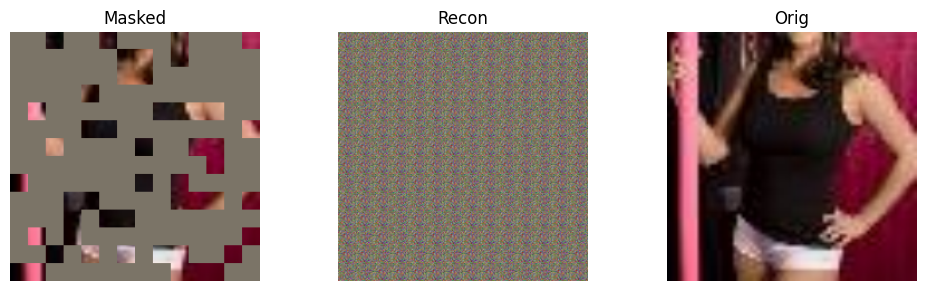

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import torch

@torch.no_grad()
def make_masked_input(imgs, mask, patch_size=16):
    patches = patchify(imgs, patch_size)
    patches2 = patches.clone()
    patches2[mask.bool()] = 0.0
    return unpatchify(patches2, patch_size, 224)

@torch.no_grad()
def reconstruct_images(model, imgs):
    model.eval()
    real_model = model.module if hasattr(model, 'module') else model
    
    pred_patches, mask = real_model(imgs)
    pred_img = unpatchify(pred_patches, real_model.patch_size, real_model.img_size)
    masked_in = make_masked_input(imgs, mask, real_model.patch_size)

    orig = denormalize(imgs).clamp(0, 1)
    rec  = denormalize(pred_img).clamp(0, 1)
    m_in = denormalize(masked_in).clamp(0, 1)
    return m_in, rec, orig, mask

@torch.no_grad()
def show_reconstructions(model, loader, n=5):
    xb, _ = next(iter(loader))
    xb = xb.to(device)[:n]
    m_in, rec, orig, mask = reconstruct_images(model, xb)
    print("Showing", n, "examples. Tensor shapes:", m_in.shape, rec.shape, orig.shape)

    fig, axes = plt.subplots(n, 3, figsize=(10, 3*n))
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        axes[i,0].imshow(m_in[i].permute(1,2,0).cpu().numpy()); axes[i,0].set_title("Masked"); axes[i,0].axis("off")
        axes[i,1].imshow(rec[i].permute(1,2,0).cpu().numpy());  axes[i,1].set_title("Recon");  axes[i,1].axis("off")
        axes[i,2].imshow(orig[i].permute(1,2,0).cpu().numpy()); axes[i,2].set_title("Orig");   axes[i,2].axis("off")
    plt.tight_layout()
    plt.show()
show_reconstructions(model, train_loader, n=1)

DataParallel wrapping + parameter count

In [11]:
use_data_parallel = torch.cuda.is_available() and torch.cuda.device_count() > 1
if use_data_parallel:
    model = nn.DataParallel(model)

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total params: {n_params:.2f}M")

Total params: 107.76M


Optimizer + scheduler + scaler (prints total steps + initial LR)

In [46]:
from torch.amp import GradScaler
from torch.cuda.amp import autocast

epochs = 30
base_lr = 1.5e-4
weight_decay = 0.05

optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
total_steps = epochs * len(train_loader)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=total_steps, eta_min=1e-6
)

scaler = GradScaler("cuda", enabled=torch.cuda.is_available())
grad_clip = 1.0

print("epochs:", epochs)
print("steps/epoch:", len(train_loader), "total_steps:", total_steps)
print("init lr:", optimizer.param_groups[0]["lr"])

epochs: 30
steps/epoch: 2083 total_steps: 62490
init lr: 0.00015


Train/Eval loops

In [48]:
from torch import nn, amp
import time

def train_one_epoch(model, loader, optimizer, scheduler, scaler, epoch, log_every=100):
    model.train()
    running = 0.0
    t0 = time.time()

    for step, (imgs, _) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        target_patches = patchify(imgs, 16)

        optimizer.zero_grad(set_to_none=True)

        # Updated autocast for latest PyTorch
        with amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            pred_patches, mask = model(imgs)
            loss = mae_loss(pred_patches, target_patches, mask)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running += loss.item()

        if (step + 1) % log_every == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"epoch {epoch} step {step+1}/{len(loader)} loss {running/(step+1):.4f} lr {lr:.2e}")

    return running / len(loader), time.time() - t0


@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    running = 0.0
    for imgs, _ in loader:
        imgs = imgs.to(device, non_blocking=True)
        target_patches = patchify(imgs, 16)
        pred_patches, mask = model(imgs)
        loss = mae_loss(pred_patches, target_patches, mask)
        running += loss.item()
    return running / len(loader)

print("Train/eval functions defined.")

Train/eval functions defined.


In [53]:
checkpoint = torch.load("model_epoch_20.pt")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

start_epoch = checkpoint['epoch'] + 1
print("Resuming from epoch:", start_epoch)

Resuming from epoch: 21


Run training

In [54]:
train_losses = []
val_losses = []

for epoch in range(start_epoch, epochs + 1):
    tr_loss, dt = train_one_epoch(model, train_loader, optimizer, scheduler, scaler, epoch, log_every=200)
    train_losses.append(tr_loss)

    if val_loader is not None:
        vl_loss = eval_one_epoch(model, val_loader)
        val_losses.append(vl_loss)
        print(f"[Epoch {epoch}/{epochs}] train_loss={tr_loss:.4f} val_loss={vl_loss:.4f} time={dt:.1f}s")
    else:
        print(f"[Epoch {epoch}/{epochs}] train_loss={tr_loss:.4f} time={dt:.1f}s")
    
    save_path = f"model_epoch_{epoch}.pt"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': tr_loss,
        'val_loss': vl_loss if val_loader is not None else None,
    }, save_path)
    print(f"Saved model checkpoint to {save_path}")

print("Done training. Final train loss:", train_losses[-1])
torch.save(model.state_dict(), "/kaggle/working/model.pth")
print("Final model saved as model.pth")

epoch 21 step 200/2083 loss 0.2506 lr 3.76e-05
epoch 21 step 400/2083 loss 0.2501 lr 3.70e-05
epoch 21 step 600/2083 loss 0.2500 lr 3.63e-05
epoch 21 step 800/2083 loss 0.2500 lr 3.57e-05
epoch 21 step 1000/2083 loss 0.2495 lr 3.51e-05
epoch 21 step 1200/2083 loss 0.2495 lr 3.44e-05
epoch 21 step 1400/2083 loss 0.2496 lr 3.38e-05
epoch 21 step 1600/2083 loss 0.2498 lr 3.32e-05
epoch 21 step 1800/2083 loss 0.2497 lr 3.26e-05
epoch 21 step 2000/2083 loss 0.2495 lr 3.20e-05
[Epoch 21/30] train_loss=0.2494 val_loss=0.2474 time=593.1s
Saved model checkpoint to model_epoch_21.pt
epoch 22 step 200/2083 loss 0.2458 lr 3.11e-05
epoch 22 step 400/2083 loss 0.2464 lr 3.05e-05
epoch 22 step 600/2083 loss 0.2465 lr 2.99e-05
epoch 22 step 800/2083 loss 0.2462 lr 2.93e-05
epoch 22 step 1000/2083 loss 0.2468 lr 2.87e-05
epoch 22 step 1200/2083 loss 0.2469 lr 2.82e-05
epoch 22 step 1400/2083 loss 0.2470 lr 2.76e-05
epoch 22 step 1600/2083 loss 0.2470 lr 2.70e-05
epoch 22 step 1800/2083 loss 0.2469 lr 2

Plot losses

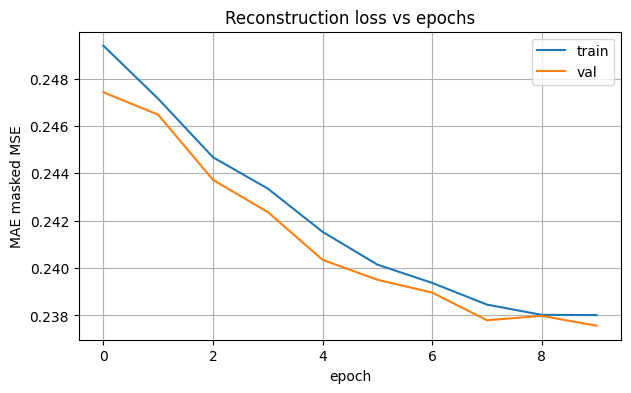

Train losses: [0.24938533922627862, 0.24714458309224863, 0.24467604395236411, 0.2433537696481495, 0.24152771284445168] ... (total: 10 )


In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(train_losses, label="train")
if len(val_losses) > 0:
    plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("MAE masked MSE")
plt.title("Reconstruction loss vs epochs")
plt.grid(True)
plt.legend()
plt.show()

print("Train losses:", train_losses[:5], "... (total:", len(train_losses), ")")

Examples

Showing 5 examples. Tensor shapes: torch.Size([5, 3, 224, 224]) torch.Size([5, 3, 224, 224]) torch.Size([5, 3, 224, 224])


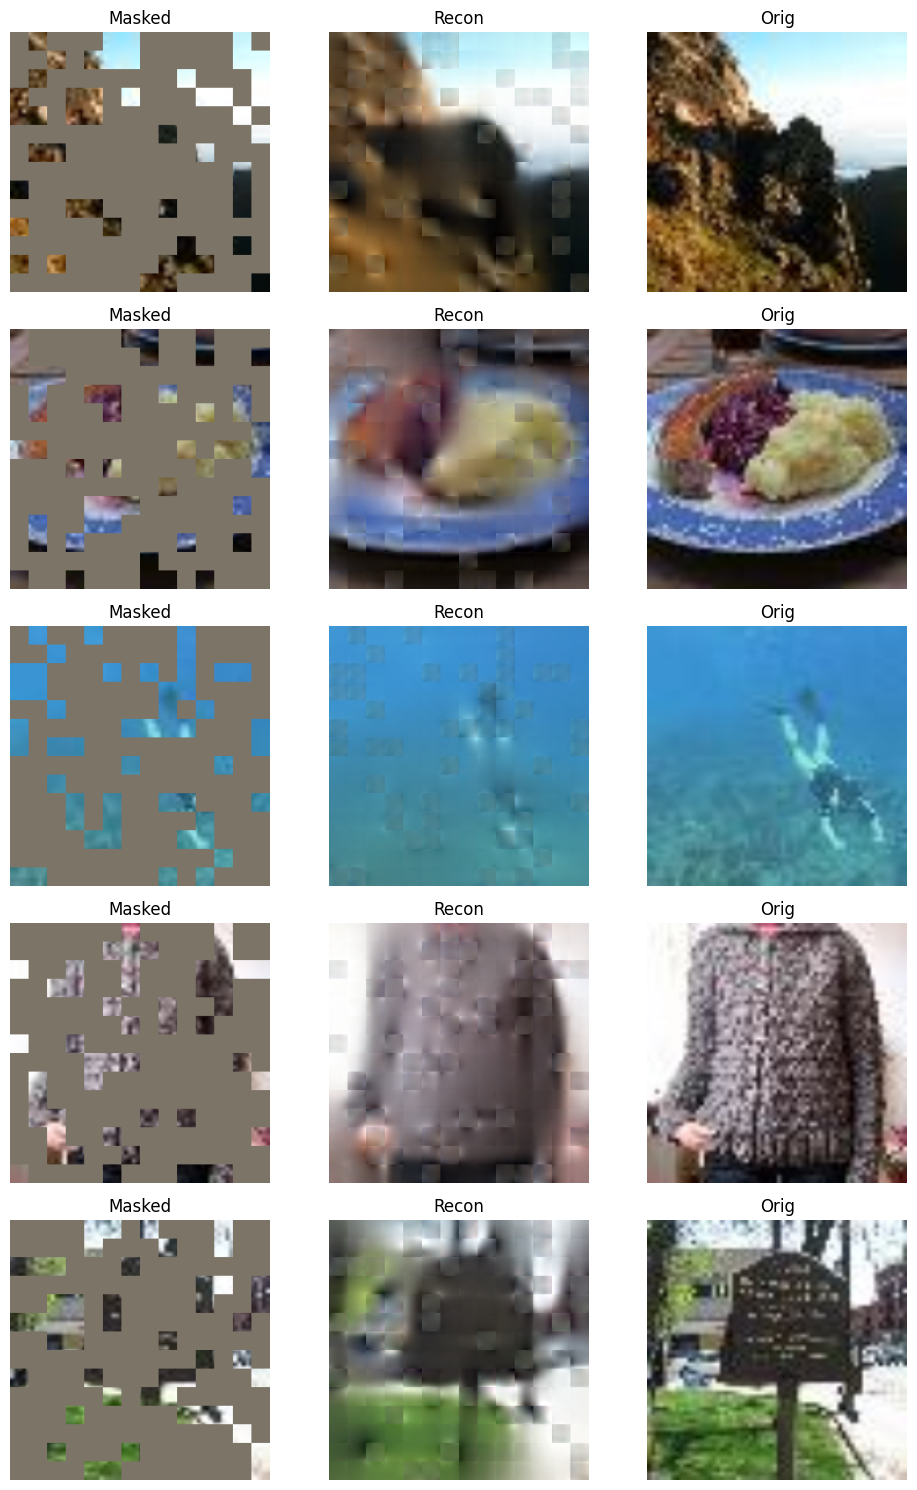

In [56]:
show_reconstructions(model, train_loader, n=5)

PSNR/SSIM evaluation

In [57]:
@torch.no_grad()
def eval_psnr_ssim(model, loader, n_batches=2):
    model.eval()
    psnrs, ssims = [], []
    for i, (imgs, _) in enumerate(loader):
        imgs = imgs.to(device)
        m_in, rec, orig, mask = reconstruct_images(model, imgs)
        p, s = compute_psnr_ssim_batch(rec, orig)
        psnrs.append(p); ssims.append(s)
        if i + 1 >= n_batches:
            break
    return float(np.mean(psnrs)), float(np.mean(ssims))

psnr, ssim = eval_psnr_ssim(model, val_loader if val_loader is not None else train_loader, n_batches=2)
print("Avg PSNR:", psnr)
print("Avg SSIM:", ssim)

Avg PSNR: 20.41994947791268
Avg SSIM: 0.5295954495668411


Save checkpoint (prints path + size)

In [58]:
ckpt_path = "/kaggle/working/mae_tinyimagenet.pth"
state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

torch.save({
    "model_state": state,
    "config": {
        "img_size": 224, "patch_size": 16, "mask_ratio": float(model.module.mask_ratio if isinstance(model, nn.DataParallel) else model.mask_ratio),
        "enc_dim": 768, "enc_depth": 12, "enc_heads": 12,
        "dec_dim": 384, "dec_depth": 12, "dec_heads": 6,
    }
}, ckpt_path)

print("Saved:", ckpt_path)
print("File size (MB):", os.path.getsize(ckpt_path) / (1024**2))

Saved: /kaggle/working/mae_tinyimagenet.pth
File size (MB): 411.1719207763672


Gradio app

In [60]:
import gradio as gr
from PIL import Image

def load_model(ckpt):
    obj = torch.load(ckpt, map_location="cpu")
    cfg = obj["config"]
    m = MAE(
        img_size=cfg["img_size"], patch_size=cfg["patch_size"], in_chans=3,
        enc_dim=cfg["enc_dim"], enc_depth=cfg["enc_depth"], enc_heads=cfg["enc_heads"],
        dec_dim=cfg["dec_dim"], dec_depth=cfg["dec_depth"], dec_heads=cfg["dec_heads"],
        mlp_ratio=4.0, mask_ratio=cfg["mask_ratio"]
    )
    m.load_state_dict(obj["model_state"], strict=True)
    m.eval()
    return m

app_model = load_model(ckpt_path).to(device)

infer_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def run_infer(pil_img, mask_ratio):
    # set mask ratio at runtime
    app_model.mask_ratio = float(mask_ratio)
    img = pil_img.convert("RGB")
    x = infer_tfms(img).unsqueeze(0).to(device)

    m_in, rec, orig, mask = reconstruct_images(app_model, x)

    def to_pil(t):
        arr = (t[0].permute(1,2,0).detach().cpu().numpy() * 255.0).astype(np.uint8)
        return Image.fromarray(arr)

    return to_pil(m_in), to_pil(rec), to_pil(orig)

demo = gr.Interface(
    fn=run_infer,
    inputs=[
        gr.Image(type="pil", label="Upload image"),
        gr.Slider(0.1, 0.9, value=0.75, step=0.05, label="Mask ratio"),
    ],
    outputs=[
        gr.Image(type="pil", label="Masked input"),
        gr.Image(type="pil", label="Reconstruction"),
        gr.Image(type="pil", label="Original (resized)"),
    ],
    title="MAE (ViT-Base encoder / ViT-Small decoder) — TinyImageNet",
)

print("Launching Gradio app...")
demo.launch(debug=False)

Launching Gradio app...
* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://7d6c3ddb1a6abb2f75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
